In [1]:
!git clone -b random120 https://github.com/cho-colette/Pelagia1.git

Cloning into 'Pelagia1'...
remote: Enumerating objects: 113, done.
remote: Counting objects: 100% (113/113), done.
remote: Compressing objects: 100% (108/108), done.
remote: Total 113 (delta 60), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (113/113), 42.03 KiB | 2.21 MiB/s, done.
Resolving deltas: 100% (60/60), done.


In [2]:
%cd /content/Pelagia1
!git branch --show-current

/content/Pelagia1
random120


In [3]:
!pip install -r requirements.txt

In [4]:
import sys

src_path = "/content/Pelagia1/src"
if src_path not in sys.path:
    sys.path.insert(0, src_path)

In [5]:
from utils import SignalConfig
from generate_signals import generate_dataset
from extract_features import build_feature_table
from train_classifier import train_classifier
from train_anomaly_model import train_anomaly_model
from streaming_update import run_streaming_update_demo
from plot_branches import plot_decision_tree_figure, plot_confusion_matrix_heatmap

In [6]:
config = SignalConfig(duration_s=120.0, sample_rate_hz=10.0, random_seed=42)
config

SignalConfig(duration_s=120.0, sample_rate_hz=10.0, random_seed=42)

In [7]:
print("1. Generating synthetic signals...")
df = generate_dataset(config=config)
print(df.shape)
df.head()

1. Generating synthetic signals...
(576000, 13)


,time_s,petal_1,petal_2,petal_3,voltage_v,current_a,power_w,energy_j,temperature_c,fold_state,state_id,state_label,case_id
0,0.0,0.005719,0.023645,-0.025211,10.444383,1.070588,11.181629,1.118163,20.560570,0.0,0,normal_harvesting,state_0_sample_000
1,0.1,0.065460,0.105266,-0.004037,10.369545,1.156705,11.994504,2.317613,20.328491,0.0,0,normal_harvesting,state_0_sample_000
2,0.2,0.102418,0.142600,0.039408,10.431841,1.282800,13.381970,3.655810,20.399268,0.0,0,normal_harvesting,state_0_sample_000
3,0.3,0.128487,0.156499,0.067505,10.638193,1.331459,14.164314,5.072242,20.410670,0.0,0,normal_harvesting,state_0_sample_000
4,0.4,0.197567,0.191198,0.123449,10.957369,1.315992,14.419815,6.514223,20.534939,0.0,0,normal_harvesting,state_0_sample_000


In [8]:
df = generate_dataset(config=config, samples_per_state=120)

In [9]:
print("2. Extracting features...")
features = build_feature_table(sample_rate_hz=config.sample_rate_hz)
print(features.shape)
features.head()

2. Extracting features...
(480, 37)


,case_id,state_id,state_label,amp_petal_1,amp_petal_2,amp_petal_3,mean_petal_1,mean_petal_2,mean_petal_3,std_petal_1,...,max_power_w,mean_dpower,max_abs_dpower,rolling_power_mean_final,rolling_power_std_final,mean_temperature_c,max_temperature_c,mean_dtemp,energy_final_j,fold_state_final
0,state_0_sample_000,0,normal_harvesting,0.254927,0.252451,0.257796,-0.008259,-0.004524,-0.003247,0.131432,...,17.696845,0.018572,23.915142,13.819956,1.387330,21.374148,22.408891,0.011994,1651.152909,0.0
1,state_0_sample_001,0,normal_harvesting,0.250069,0.248701,0.269576,0.008220,0.002482,0.005058,0.133837,...,20.034509,0.029378,24.252650,14.369753,2.089956,21.554812,22.348881,0.010613,1742.512783,0.0
2,state_0_sample_002,0,normal_harvesting,0.261250,0.253088,0.264929,0.010246,0.004233,0.009375,0.130367,...,17.413813,-0.023255,28.248541,12.725093,1.257465,20.920866,21.691506,0.008074,1587.713870,0.0
3,state_0_sample_003,0,normal_harvesting,0.211954,0.224188,0.225808,0.002040,0.002166,-0.002571,0.109805,...,16.295145,0.030267,20.934603,12.630047,1.103037,21.785907,22.768129,0.007205,1525.541024,0.0
4,state_0_sample_004,0,normal_harvesting,0.280735,0.279354,0.279528,-0.002628,0.007760,0.006340,0.141783,...,17.652632,0.019468,23.366964,12.682420,1.261918,21.698278,22.507297,0.011503,1587.959828,0.0


In [10]:
print("3. Training classifier...")
classifier_outputs = train_classifier()
print(classifier_outputs["metrics"])
print(classifier_outputs["confusion_df"])

3. Training classifier...
{'accuracy': 0.975, 'n_train': 360, 'n_test': 120, 'n_features': 25, 'classes': ['adaptive_operation', 'anomaly_inspection', 'normal_harvesting', 'protective_mode']}
                    adaptive_operation  anomaly_inspection  normal_harvesting  \
adaptive_operation                  28                   1                  1   
anomaly_inspection                   1                  29                  0   
normal_harvesting                    0                   0                 30   
protective_mode                      0                   0                  0   

                    protective_mode  
adaptive_operation                0  
anomaly_inspection                0  
normal_harvesting                 0  
protective_mode                  30  


In [11]:
print("4. Training anomaly model...")
anomaly_outputs = train_anomaly_model()
print(anomaly_outputs)

4. Training anomaly model...
{'model': IsolationForest(contamination=0.08, n_estimators=300, random_state=42), 'scaler': StandardScaler(), 'results':                 case_id        state_label  anomaly_score  anomaly_flag  \
0    state_0_sample_000  normal_harvesting       0.133041             1   
1    state_0_sample_001  normal_harvesting       0.121668             1   
2    state_0_sample_002  normal_harvesting       0.070736             1   
3    state_0_sample_003  normal_harvesting      -0.012078            -1   
4    state_0_sample_004  normal_harvesting       0.108930             1   
..                  ...                ...            ...           ...   
475  state_3_sample_115    protective_mode      -0.146491            -1   
476  state_3_sample_116    protective_mode      -0.155772            -1   
477  state_3_sample_117    protective_mode      -0.132799            -1   
478  state_3_sample_118    protective_mode      -0.144097            -1   
479  state_3_sample_119  

In [12]:
print("5. Running streaming update demo...")
stream_outputs = run_streaming_update_demo()
print(stream_outputs)

5. Running streaming update demo...
{'model': SGDClassifier(loss='log_loss', max_iter=1, random_state=42, tol=None), 'metrics_df':     samples_seen  batch_end_index  running_accuracy
0              8                8          0.375000
1             16               16          0.250000
2             24               24          0.125000
3             32               32          0.343750
4             40               40          0.350000
5             48               48          0.354167
6             56               56          0.410714
7             64               64          0.359375
8             72               72          0.361111
9             80               80          0.250000
10            88               88          0.261364
11            96               96          0.239583
12           104              104          0.355769
13           112              112          0.330357
14           120              120          0.300000
15           128              128    

In [13]:
print("6. Plotting figures...")
out_tree = plot_decision_tree_figure(fontsize=32)
out_cm = plot_confusion_matrix_heatmap()

print("Decision tree:", out_tree)
print("Confusion matrix:", out_cm)

6. Plotting figures...
Decision tree: figures/pelagia_decision_tree.png
Confusion matrix: figures/pelagia_confusion_matrix.png


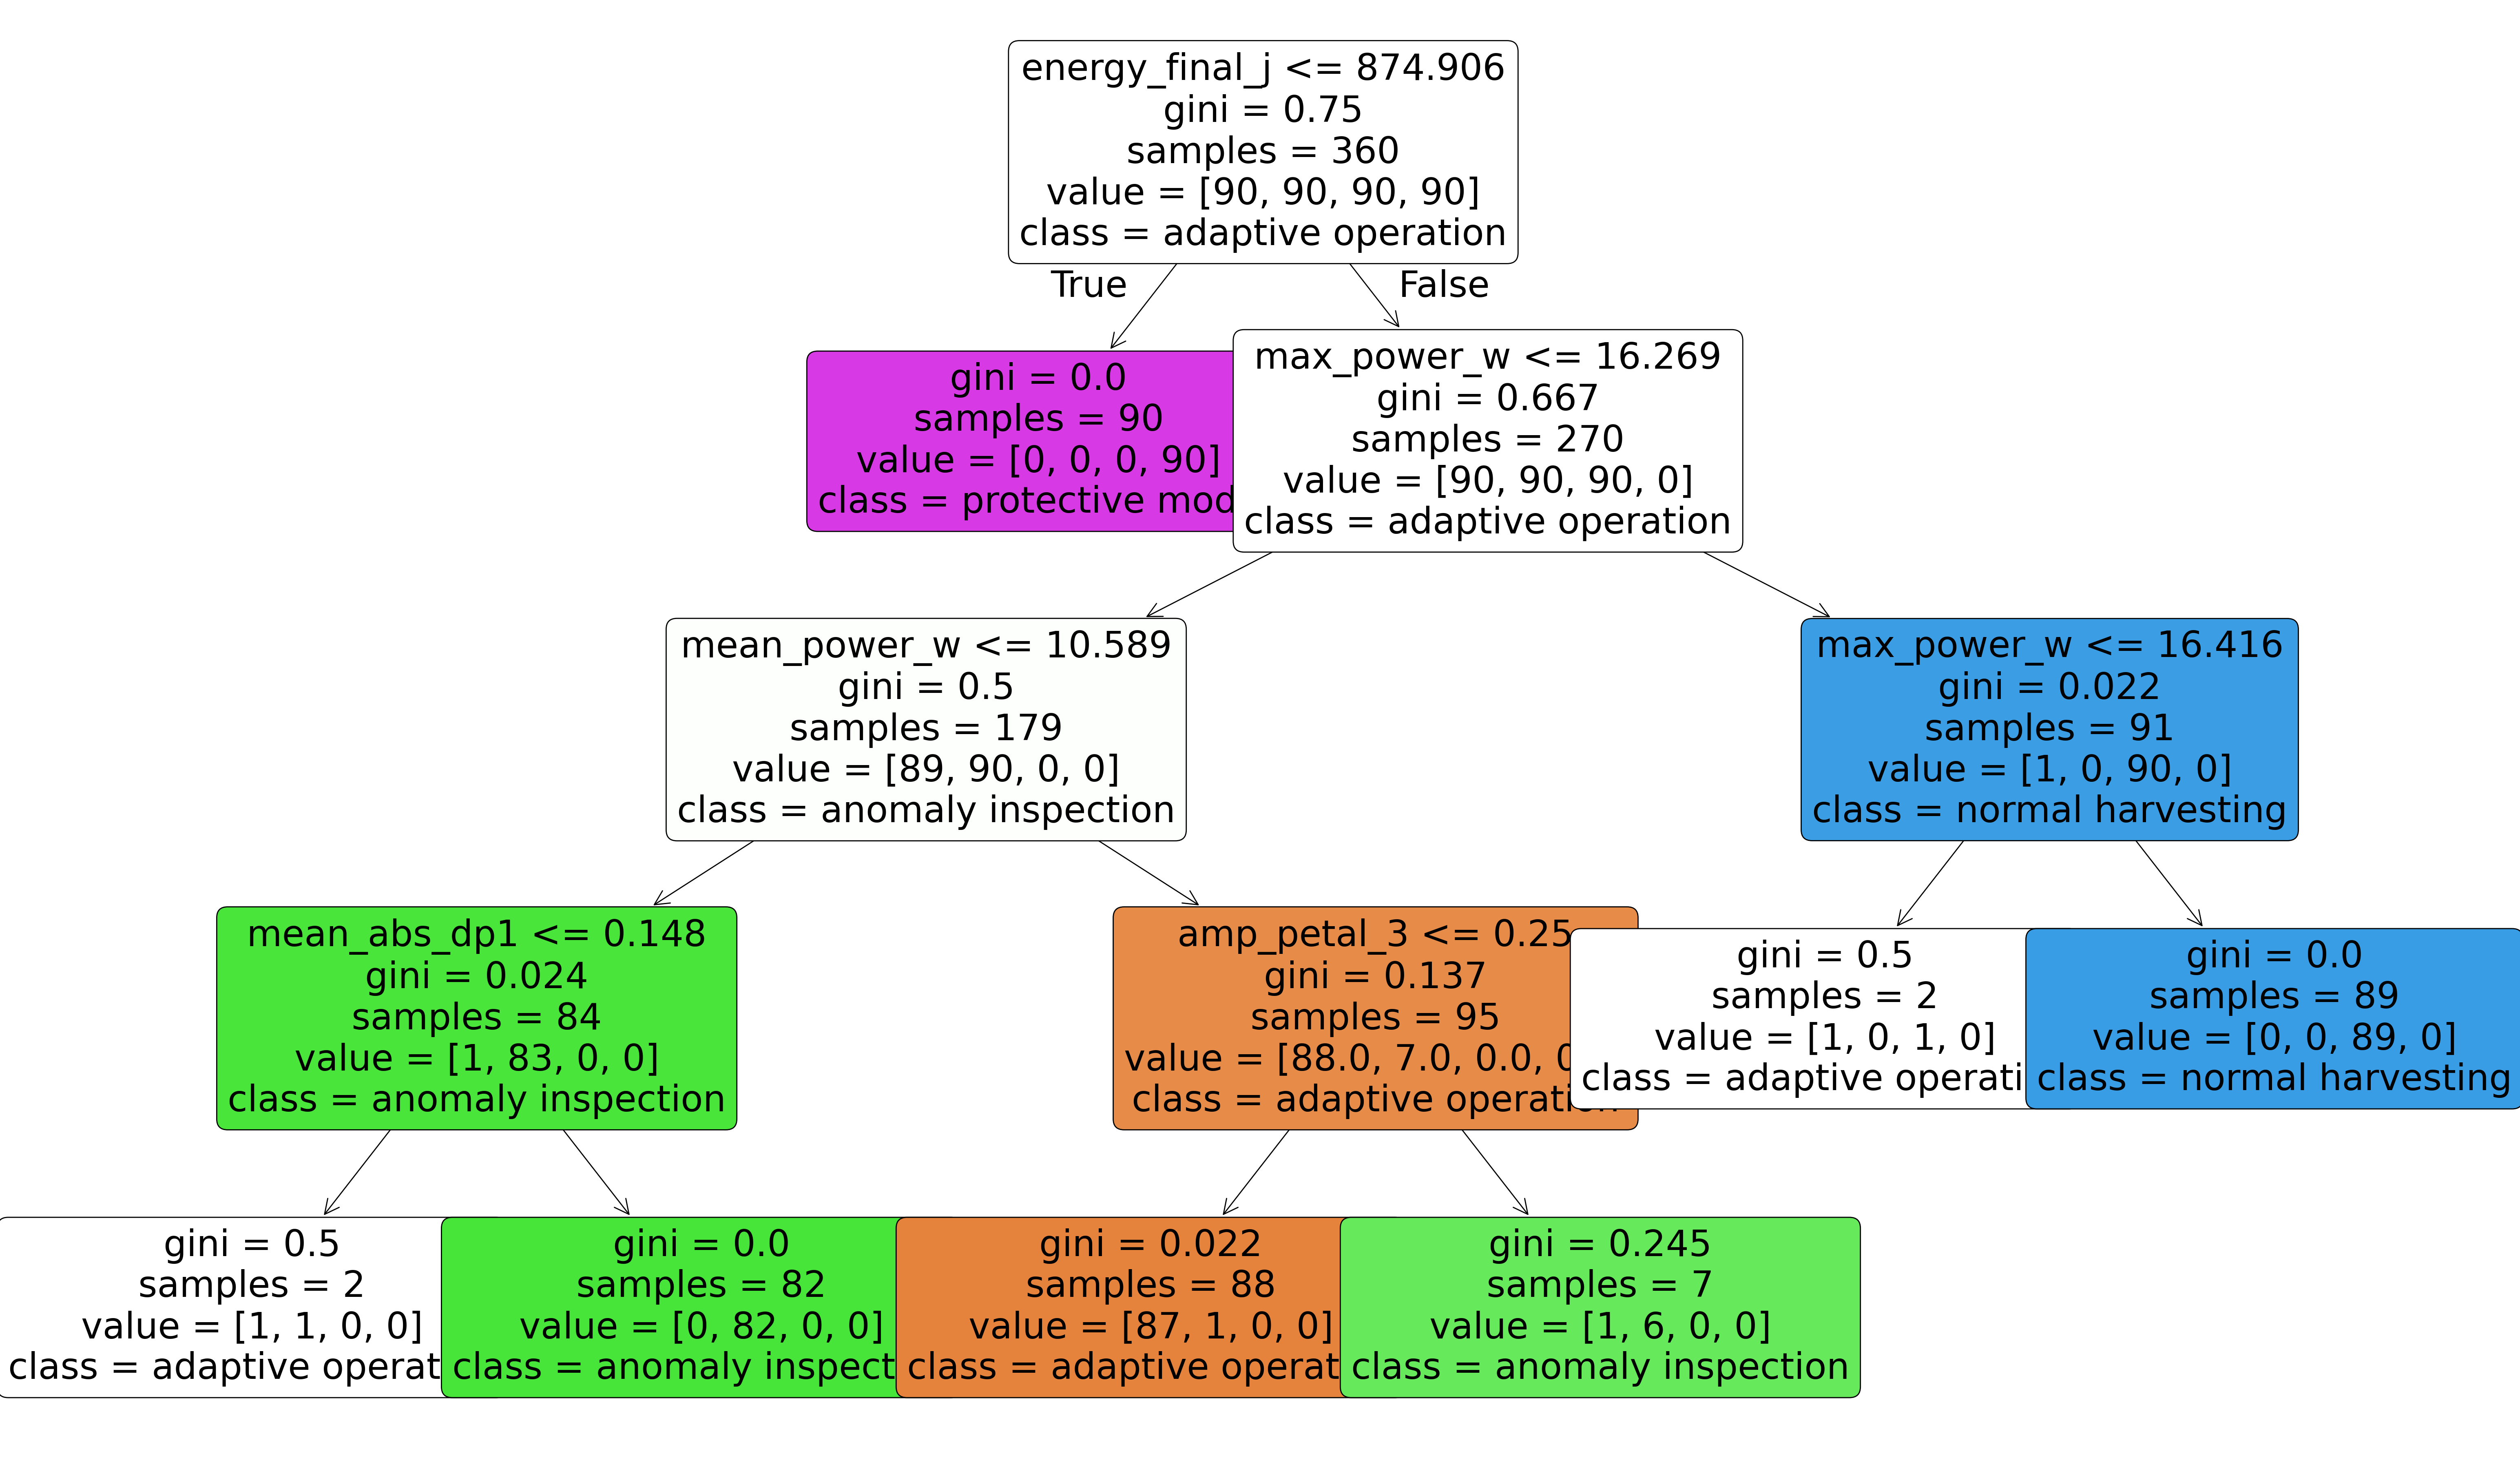

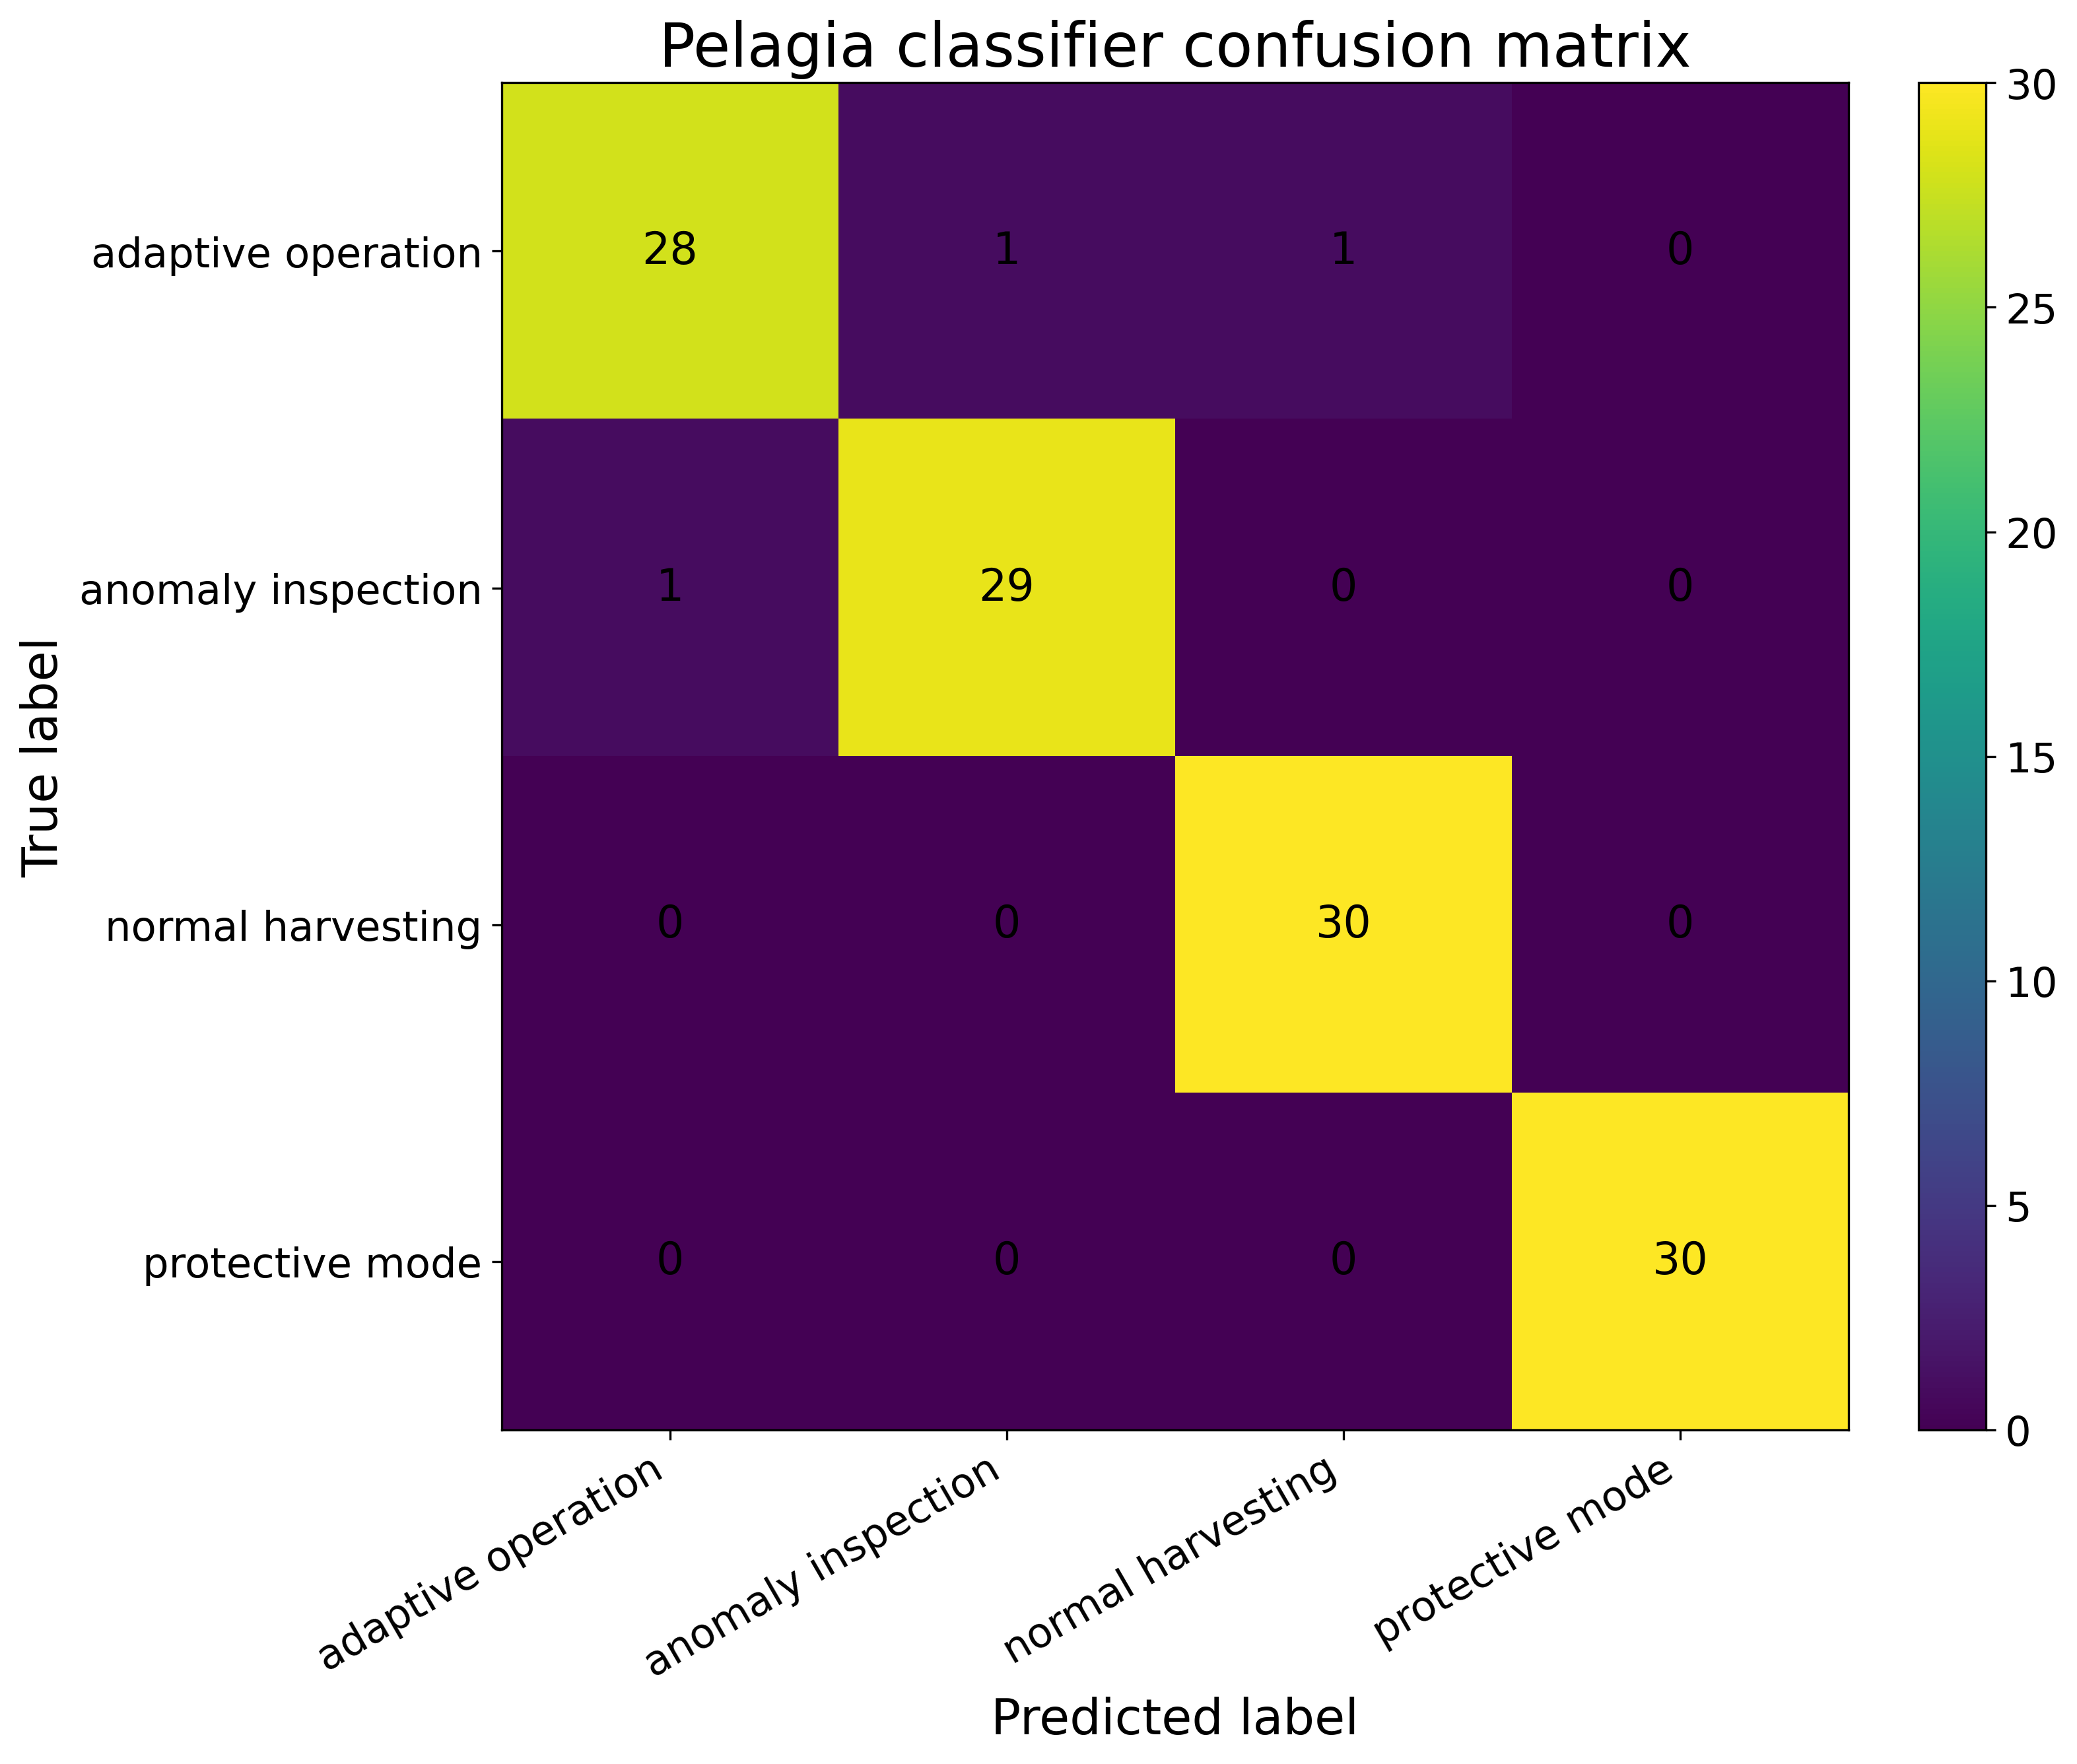

In [14]:
from IPython.display import Image, display

display(Image(filename=str(out_tree)))
display(Image(filename=str(out_cm)))

In [15]:
import shutil
from pathlib import Path
from google.colab import files

source_dir = Path("/content/Pelagia1/figures")
bundle_dir = Path("/content/pelagia_random120_figures")

if bundle_dir.exists():
    shutil.rmtree(bundle_dir)
bundle_dir.mkdir(parents=True, exist_ok=True)

for name in ["pelagia_decision_tree.png", "pelagia_confusion_matrix.png"]:
    src = source_dir / name
    if src.exists():
        shutil.copy(src, bundle_dir / name)
        print("Added:", name)
    else:
        print("Missing:", name)

zip_path = shutil.make_archive("/content/pelagia_random120_figures", "zip", bundle_dir)
print("Created:", zip_path)
files.download(zip_path)

Added: pelagia_decision_tree.png
Added: pelagia_confusion_matrix.png
Created: /content/pelagia_random120_figures.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved to: figures/pelagia_decision_tree.png


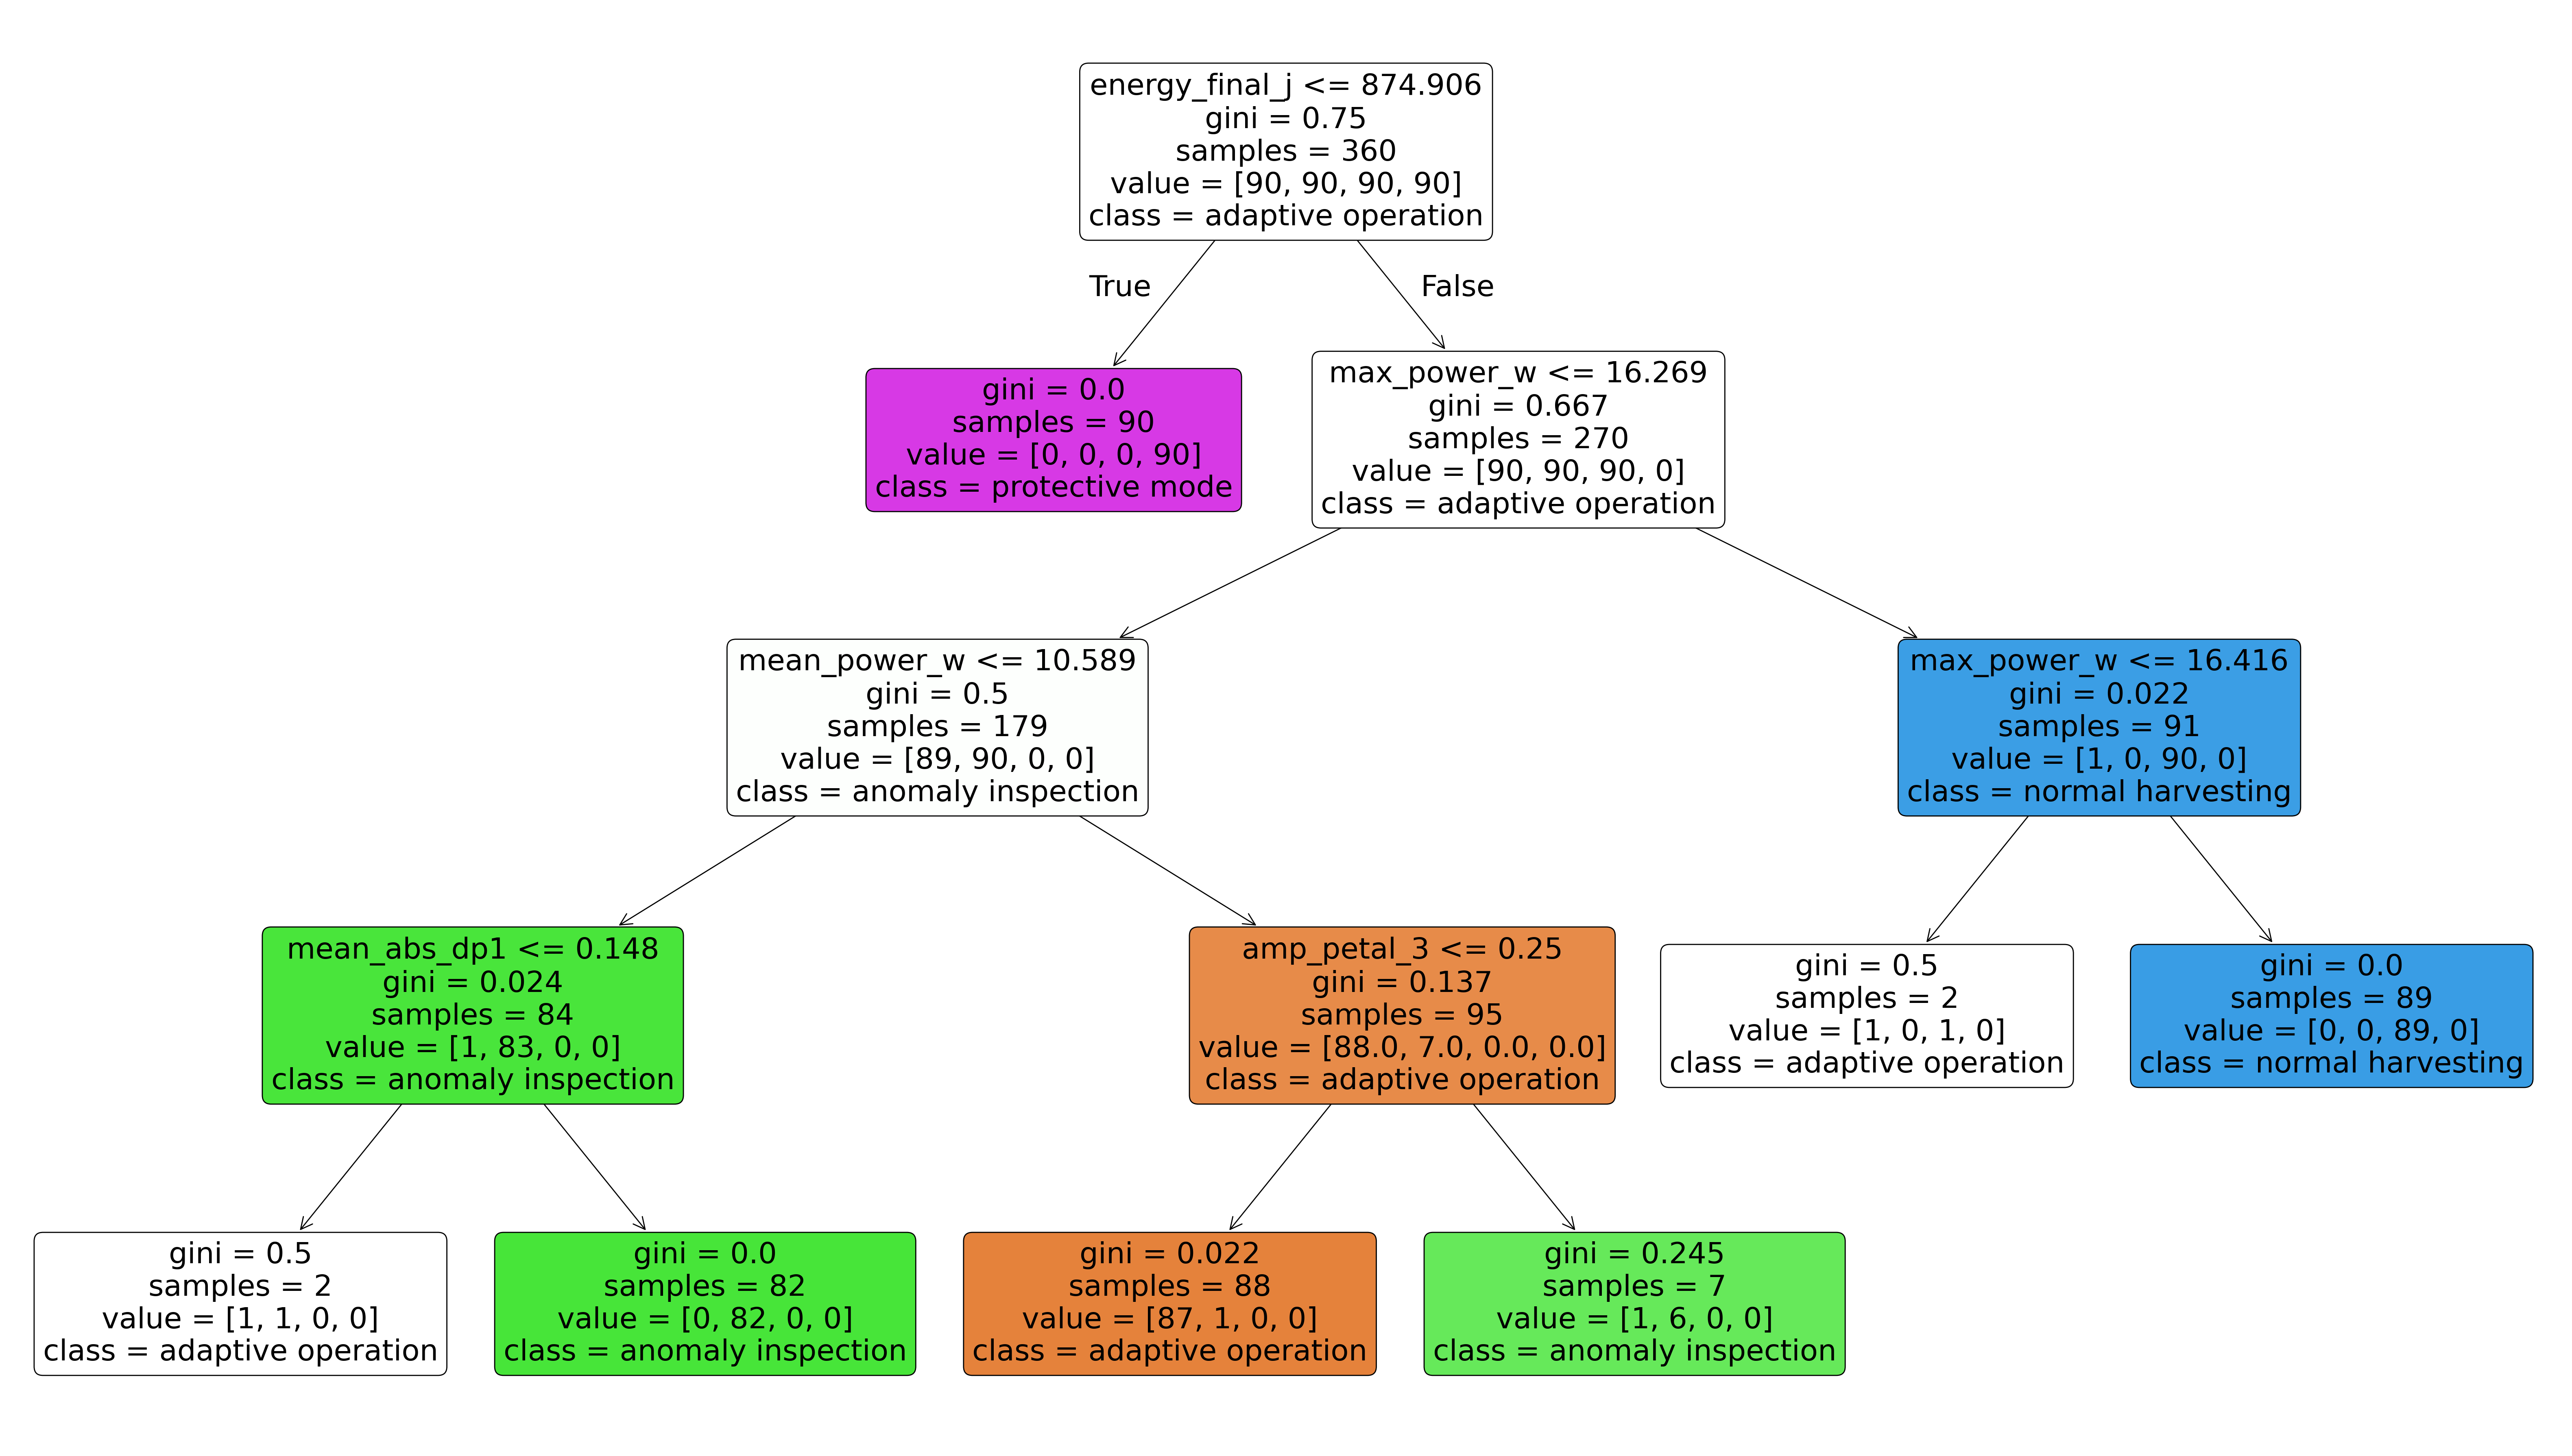

In [18]:
from plot_branches import plot_decision_tree_figure
from IPython.display import Image, display

out_tree = plot_decision_tree_figure(fontsize=26)
print("Saved to:", out_tree)

display(Image(filename=str(out_tree)))

In [19]:
from google.colab import files
files.download(str(out_tree))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>